In [280]:
import pandas as pd
import re
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

import os
def get_indiv_concepts(formula) -> list:
    concepts = []
    concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', formula)
    for c in concps:
        try:
            end_idx = c.index(')')
        except:
            end_idx = len(c)
        concepts.append(c[:end_idx])
    return concepts



def load_csv_data(filepath):
    """Load CSV and extract unit-concept mappings."""
    df = pd.read_csv(filepath)

    unit_concepts = defaultdict(set)
    raw_concepts= []
    for _, row in df.iterrows():
        unit = row['unit']
        formula = row['best_name']
        concepts = get_indiv_concepts(formula)
        
        unit_concepts[unit].update(concepts)
        raw_concepts.extend(concepts)
        
    return unit_concepts


def get_all_cps_for_pi(folder):
    root_path = Path(folder)

    # Find all matching CSV files
    csv_pattern = 'Cluster*IOUS1024N.csv'
    csv_files = list(root_path.rglob(csv_pattern))
    
    concept_dict=defaultdict(set)
    for csv_file in csv_files:
  
        concepts = []
        csv_file = os.path.join(folder, csv_file)
        df = pd.read_csv(csv_file)
        for unit, formula in zip(df.unit, df.best_name):
            concept_dict[unit].update(get_indiv_concepts(formula))
    return concept_dict

def get_cluster_cps_for_pi(folder, cluster):
    csv_file = f'Cluster{cluster}IOUS1024N.csv'
    
    concept_dict=defaultdict(set)
    concepts = []
    csv_file = os.path.join(folder, csv_file)
    df = pd.read_csv(csv_file)
    for unit, formula in zip(df.unit, df.best_name):
        concept_dict[unit].update(get_indiv_concepts(formula))
    return concept_dict


In [272]:
def get_cp_neuron_mapping(cps_dict):
    mapping=defaultdict(set)
    for unit, cp in cps_dict.items():
        for c in cp:
            mapping[c].add(unit)
    return mapping

In [275]:
avg=0
fn=get_cp_neuron_mapping
avgsnsc=0
for i in [5,6,7]:
    dense_concepts=get_all_cps_for_pi(f'/workspace/CCE_NLI/BERT/lottery_ticket/Run0.25_{i}/Expls/0.0%Pruned')
    sparse_concepts=get_all_cps_for_pi(f'/workspace/CCE_NLI/BERT/lottery_ticket/Run0.25_{i}/Expls/25.0%Pruned')
    
    dense_concepts_c1, draw1=load_csv_data(f'/workspace/CCE_NLI/BERT/lottery_ticket/Run0.25_{i}/Expls/0.0%Pruned/Cluster1IOUS1024N.csv')
    sparse_concepts_c1, sraw1=load_csv_data(f'/workspace/CCE_NLI/BERT/lottery_ticket/Run0.25_{i}/Expls/25.0%Pruned/Cluster1IOUS1024N.csv')
    dense_concepts_c2, draw2=load_csv_data(f'/workspace/CCE_NLI/BERT/lottery_ticket/Run0.25_{i}/Expls/0.0%Pruned/Cluster2IOUS1024N.csv')
    sparse_concepts_c2, sraw2=load_csv_data(f'/workspace/CCE_NLI/BERT/lottery_ticket/Run0.25_{i}/Expls/25.0%Pruned/Cluster2IOUS1024N.csv')
    dense_concepts_c3, draw3=load_csv_data(f'/workspace/CCE_NLI/BERT/lottery_ticket/Run0.25_{i}/Expls/0.0%Pruned/Cluster3IOUS1024N.csv')
    sparse_concepts_c3, sraw3=load_csv_data(f'/workspace/CCE_NLI/BERT/lottery_ticket/Run0.25_{i}/Expls/25.0%Pruned/Cluster3IOUS1024N.csv')
    
    dense_concepts_per_cluster_mp = [fn(dense_concepts_c1), fn(dense_concepts_c2), fn(dense_concepts_c3)]
    sparse_concepts_per_cluster_mp = [fn(sparse_concepts_c1), fn(sparse_concepts_c2), fn(sparse_concepts_c3)]

    dense_concepts_per_cluster_raw = [draw1, draw2, draw3]
    sparse_concepts_per_cluster_raw = [sraw1, sraw2, sraw3]
    
    global_dense = set.union(*dense_concepts.values())
    global_sparse = set.union(*sparse_concepts.values())
    ttl=len(global_dense)
    dense_map=fn(dense_concepts)
    sparse_map=fn(sparse_concepts)
    snsc=0
    dnsc=0
    sndc=0
    dndc=0
    l=0
    for dense_clus_mp, d_raw, sparse_clus_mp, s_raw in zip(dense_concepts_per_cluster_mp, dense_concepts_per_cluster_raw, sparse_concepts_per_cluster_mp, sparse_concepts_per_cluster_raw):
        for cp, neuron in dense_clus_mp.items():
            if dense_clus_mp[cp].intersection(sparse_clus_mp.get(cp,set())): #same nuron same c
                snsc += 1
                
            elif d_raw.intersection(s_raw):
                dnsc += 1
            elif dense_clus_mp[cp].intersection(sparse_map.get(cp,set())): #same neuron dif clus
                sndc += 1
            elif cp in global_dense.intersection(global_sparse):
                dndc += 1
            else:
                l += 1
            
    avgsnsc += snsc/ttl
    avg += 1 - len(global_sparse&global_dense)/len(global_dense)
avg/3, avgsnsc/3

(0.24779361846571624, 0.4996605566870332)

In [256]:
(0.38142620232172475+0.40327868852459015+0.3867768595041322)/3

0.3904939167834824

REDUNDANCY


  LLAMA  /  lottery_ticket

  Cluster 1:
    Sparsity       Mean        Std     N
  ----------------------------------------
           0    12.1333     0.0000     3
           1    13.7438     0.3983     3
           2    13.7802     0.4128     3
           3    14.8800     0.3924     3
           4    14.1345     0.2619     3
           5    14.1910     0.2170     3

  Cluster 2:
    Sparsity       Mean        Std     N
  ----------------------------------------
           0    12.9891     0.0000     3
           1    12.5644     0.5287     3
           2    11.9943     0.4082     3
           3    11.9990     0.4799     3
           4    12.0355     0.1772     3
           5    11.9585     0.6600     3

  Cluster 3:
    Sparsity       Mean        Std     N
  ----------------------------------------
           0     8.5000     0.0000     3
           1     8.7036     0.2151     3
           2     8.2401     0.1799     3
           3     8.4243     0.1321     3
           4     8.159

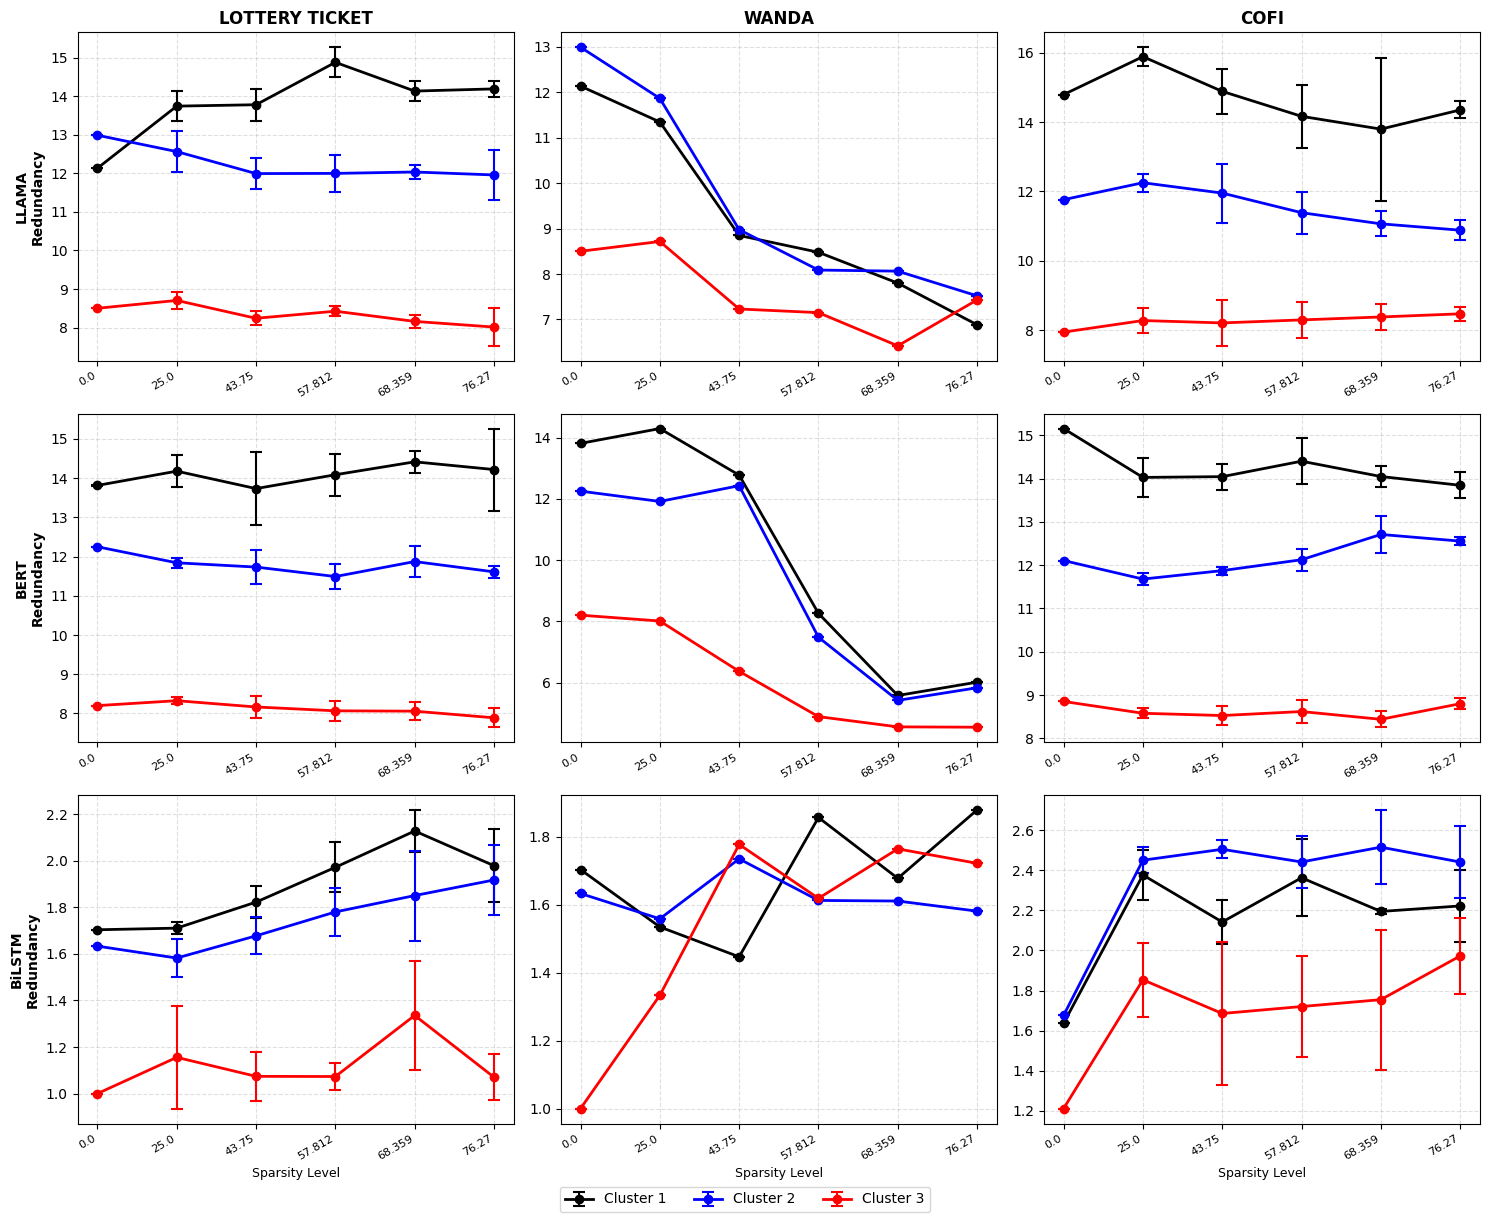

Saved → redundancy_grid.png


In [371]:
def collect_avg_freqs(expls_dict):
    concept_units = defaultdict(set)
    all_cps = []
    for unit, concepts in expls_dict.items():
        all_cps.extend(concepts)
    red = len(all_cps) / len(set(all_cps))
    return red

def collect_all_avg_freqs(base_path):
    """
    Returns: run_data[filename][sparsity_idx][cluster] = redundancy float
    """
    run_data = defaultdict(lambda: defaultdict(dict))

    for filename in sorted(os.listdir(base_path)):
        if '.ipynb' in filename or '_4cl' in filename:
            continue
        expls_path = os.path.join(base_path, filename, 'Expls')
        if not os.path.exists(expls_path):
            continue

        dense_absent = '0.0%Pruned' not in os.listdir(expls_path)
        sparsity_idx = 1 if dense_absent else 0

        for sparsity in sorted(os.listdir(expls_path)):
            if '.ipynb' in sparsity:
                continue

            for cl in cluster_range:
                path = os.path.join(expls_path, sparsity, f'Cluster{cl}IOUS1024N.csv')
                if not os.path.exists(path):
                    continue
                expls_dict = get_cluster_cps_for_pi(os.path.join(expls_path, sparsity), cl)
                red = collect_avg_freqs(expls_dict)
                if red is not None:
                    run_data[filename][sparsity_idx][cl] = red

            sparsity_idx += 1

    return run_data
mapp = {"BERT":"BERT",'BOWMAN':"BiLSTM", 'LLAMA':'LLAMA'}

def aggregate_across_runs(run_data):
    """
    Returns: stats[cluster][sparsity_idx] = {'mean', 'std', 'n', 'values'}
    """
    # sparsity_values[cluster][sparsity_idx] = [red_run1, red_run2, ...]
    sparsity_values = defaultdict(lambda: defaultdict(list))

    for filename, sparsity_dict in run_data.items():
        for sparsity_idx, cluster_dict in sparsity_dict.items():
            for cl, red in cluster_dict.items():
                sparsity_values[cl][sparsity_idx].append(red)

    stats = {}
    for cl, sp_dict in sparsity_values.items():
        stats[cl] = {}
        for sparsity_idx, values in sorted(sp_dict.items()):
            stats[cl][sparsity_idx] = {
                'mean':   np.mean(values),
                'std':    np.std(values),
                'n':      len(values),
                'values': values,
            }
    return stats
pi_map={0:0.0, 1:25.0, 2: 43.75, 3: 57.812, 4: 68.359, 5:76.27}
def plot_all_stats(all_stats, models, methods, cluster_range, sparsity_labels=None):
    n_rows = len(models)
    n_cols = len(methods)
    colors = ['black', 'blue', 'red']

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5 * n_cols, 4 * n_rows),
                             sharex=False, sharey=False)

    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes[np.newaxis, :]
    elif n_cols == 1:
        axes = axes[:, np.newaxis]

    legend_handles = []  # collect once, reuse for shared legend

    for r, model in enumerate(models):
        for c, method in enumerate(methods):
            ax = axes[r][c]

            if model not in all_stats or method not in all_stats[model]:
                ax.set_visible(False)
                continue

            stats = all_stats[model][method]

            for cl_idx, cl in enumerate(cluster_range):
                if cl not in stats:
                    continue

                sp_indices = sorted(stats[cl].keys())
                means = [stats[cl][i]['mean'] for i in sp_indices]
                stds  = [stats[cl][i]['std']  for i in sp_indices]
                color = colors[cl_idx % len(colors)]
                xs    = list(range(len(sp_indices)))

                line = ax.errorbar(
                    xs, means, yerr=stds,
                    marker='o', linewidth=2,
                    capsize=4, capthick=1.5, elinewidth=1.5,
                    color=color, ecolor=color,
                    label=f'Cluster {cl}'
                )

                # Collect handles only once (from first subplot)
                if r == 0 and c == 0:
                    legend_handles.append(line)

            tick_labels = sparsity_labels if sparsity_labels else [str(pi_map[i]) for i in sp_indices]
            ax.set_xticks(xs)
            ax.set_xticklabels(tick_labels, fontsize=8, rotation=30, ha='right')
            ax.grid(True, linestyle='--', alpha=0.4)

            if r == 0:
                ax.set_title(" ".join(method.split("_")).upper(), fontsize=12, fontweight='bold')
            if c == 0:
                ax.set_ylabel(f'{mapp[model]}\nRedundancy', fontsize=10, fontweight='bold')
            if r == n_rows - 1:
                ax.set_xlabel('Sparsity Level', fontsize=9)

    

    # Single shared legend centered below all subplots
    fig.legend(handles=legend_handles,
               labels=[f'Cluster {cl}' for cl in cluster_range],
               loc='lower center',
               ncol=len(cluster_range),
               fontsize=10,
               frameon=True,
               bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()
    plt.savefig('redundancy_grid.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → redundancy_grid.png")
def print_all_stats(all_stats, models, methods, cluster_range):
    for model in models:
        for method in methods:
            if model not in all_stats or method not in all_stats[model]:
                continue
            print(f"\n{'='*60}")
            print(f"  {model.upper()}  /  {method}")
            print(f"{'='*60}")
            stats = all_stats[model][method]
            for cl in cluster_range:
                if cl not in stats:
                    continue
                print(f"\n  Cluster {cl}:")
                print(f"  {'Sparsity':>10} {'Mean':>10} {'Std':>10} {'N':>5}")
                print(f"  {'-'*40}")
                for sp_idx in sorted(stats[cl].keys()):
                    s = stats[cl][sp_idx]
                    print(f"  {sp_idx:>10} {s['mean']:>10.4f} {s['std']:>10.4f} {s['n']:>5}")


# ── main ──────────────────────────────────────────────────────────────────────
if __name__ == "__main__":

    all_stats = {model: {} for model in models}

    for model in models:
        for method in methods:
            base_path = f"/workspace/CCE_NLI/{model.upper()}/{method}"
            if not os.path.exists(base_path):
                print(f"Skipping {model}/{method} — path not found")
                continue
            run_data = collect_all_avg_freqs(base_path)
            all_stats[model][method] = aggregate_across_runs(run_data)

    print_all_stats(all_stats, models, methods, cluster_range)

    # Optional: pass real sparsity % labels if you know the mapping
    # e.g. sparsity_labels = ['0%', '25%', '50%', '75%', '90%']
    plot_all_stats(all_stats, models, methods, cluster_range)

CONCEPT MIGRATION

In [372]:
CLUSTERS = ['Cluster1', 'Cluster2', 'Cluster3']
import json 
def load_mappings(path="/workspace/CCE_NLI/PaperExpOnly/sparse_to_dense.json"):
    with open(path, 'r') as f:
        raw = json.load(f)
    mappings = {}
    for model, methods_dict in raw.items():
        mappings[model] = {}
        for method, runs_dict in methods_dict.items():
            mappings[model][method] = {}
            for run, iters_dict in runs_dict.items():
                mappings[model][method][run] = {}
                for iter_str, mapping in iters_dict.items():
                    mappings[model][method][run][int(iter_str)] = {
                        int(k): v for k, v in mapping.items()
                    }
    return mappings


# → int (sparse equivalent) or None (pruned)


# Access:
# mappings[model][method][run_folder][pruning_iter][dense_neuron]
# e.g.


def save_cross_cluster_summary(avg_cc, model, method, out_dir='.'):
    if not avg_cc:
        return
    os.makedirs(out_dir, exist_ok=True)
    path = os.path.join(out_dir, f'{model}_{method}_cross_cluster.csv')
    fieldnames = [
        'model', 'method', 'sparsity', 'total_baseline', 'total_curr',
        'pct_same_n_same_c', 'std_same_n_same_c',
        'pct_same_n_diff_c', 'std_same_n_diff_c',
        'pct_diff_n_same_c', 'std_diff_n_same_c',
        'pct_diff_n_diff_c', 'std_diff_n_diff_c',
        'pct_disappeared',   'std_disappeared',
    ]
    with open(path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for r in avg_cc:
            writer.writerow({
                'model':                model,
                'method':               method,
                'sparsity':             r['sparsity'],
                'total_baseline':       r['total_baseline'],
                'total_curr':           r['total_curr'],
                'pct_same_n_same_c':    round(r['pct_same_n_same_c'],             4),
                'std_same_n_same_c':    round(r.get('pct_same_n_same_c_std', 0),  4),
                'pct_same_n_diff_c':    round(r['pct_same_n_diff_c'],             4),
                'std_same_n_diff_c':    round(r.get('pct_same_n_diff_c_std', 0),  4),
                'pct_diff_n_same_c':    round(r['pct_diff_n_same_c'],             4),
                'std_diff_n_same_c':    round(r.get('pct_diff_n_same_c_std', 0),  4),
                'pct_diff_n_diff_c':    round(r['pct_diff_n_diff_c'],             4),
                'std_diff_n_diff_c':    round(r.get('pct_diff_n_diff_c_std', 0),  4),
                'pct_disappeared':      round(r['pct_disappeared'],               4),
                'std_disappeared':      round(r.get('pct_disappeared_std', 0),    4),
            })
    print(f"Saved → {path}")

def get_sparsity_levels(expls_dir):
    """Return sorted list of sparsity floats found in an Expls directory."""
    sparsities = []
    for name in os.listdir(expls_dir):
        m = re.match(r'([0-9.]+)%Pruned', name)
        if m:
            sparsities.append(float(m.group(1)))
    return sorted(sparsities)


def save_per_cluster_summary(avg_pc, model, method, out_dir='.'):
    if not avg_pc:
        return
    os.makedirs(out_dir, exist_ok=True)
    path = os.path.join(out_dir, f'{model}_{method}_per_cluster.csv')
    fieldnames = [
        'model', 'method', 'cluster', 'sparsity',
        'total_baseline', 'total_curr',
        'pct_stayed',      'std_stayed',
        'pct_moved',       'std_moved',
        'pct_disappeared', 'std_disappeared',
    ]
    with open(path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        print(avg_pc.keys())
        for cl, rows in avg_pc.items():
            for r in rows:
                writer.writerow({
                    'model':            model,
                    'method':           method,
                    'cluster':          cl,
                    'sparsity':         r['sparsity'],
                    'total_baseline':   r['total_baseline'],
                    'total_curr':       r['total_curr'],
                    'pct_stayed':       round(r['pct_stayed'],                  4),
                    'std_stayed':       round(r.get('pct_stayed_std', 0),       4),
                    'pct_moved':        round(r['pct_moved'],                   4),
                    'std_moved':        round(r.get('pct_moved_std', 0),        4),
                    'pct_disappeared':  round(r['pct_disappeared'],             4),
                    'std_disappeared':  round(r.get('pct_disappeared_std', 0),  4),
                })
    print(f"Saved → {path}")

mappings = load_mappings()
#what did i do i got the pruned neurons using the final hidden mlp zs and did the reindexing (if dense 5 it pruned out then it sparse 5is equivalent to dense 6 for ex )
# i saved it into a json {model, file, sparse:dense equiv} (if the sparse neuron was pruned out if does not have a dense equivalent so its not in the mapping)
#how to use it:
#for each concept find which sparse neurons explain it and record only the equivalent dense neurons (not the sparse neurons) 
# then run the same/diff as established earlier
def find_equivalent_unit(sparse_unit, model, method, file, sparsity_idx):
    
    #print(model, method, file, sparsity_idx, sparse_unit,  mappings[model][method][file][sparsity_idx].keys())
    return mappings[model][method][file][sparsity_idx][sparse_unit]
 
def build_concept_to_units(unit_concepts_dict, dense_uc, expls_dir, s_idx):
    concept_to_units = defaultdict(set)
    for sparse_unit, concepts in unit_concepts_dict.items():
        for concept in concepts:
            if 'CoFi' in expls_dir and s_idx>0:
                if 'LLAMA' in expls_dir: 
                    model = 'LLAMA'
                elif 'BERT' in expls_dir:
                    model = 'BERT'
                elif 'BOWMAN' in expls_dir:
                    model='BOWMAN'
                else:
                    raise Error (f"invalid model in {expls_dir}")
                
                if 'Run0.25_5' in expls_dir:
                    file = 'Run0.25_5'
                elif 'Run0.25_6' in expls_dir:
                    file = 'Run0.25_6'
                elif 'Run0.25_7' in expls_dir:
                    file = 'Run0.25_7'
                else:
                    raise Error(f"Ivlaid file name in {expls_dir}")
                
                dense_equivalents = find_equivalent_unit(sparse_unit, model, 'CoFi', file, s_idx) #finds equiv dense neurons but those dense neurons might not be explainable at this cluster so need to filter
                
                #dense_equivalents_that_are_expl_in_that_cluster = [unit for unit in dense_equivalents if unit in dense_uc.keys()] #now these are the equiv units explble in same cluster
                if dense_equivalents in dense_uc.keys():
                    concept_to_units[concept].add(dense_equivalents)
            else:
                concept_to_units[concept].add(sparse_unit) #find the neurins that expl this vp (edit for cofi is find_equiv_unit which takes the mapping)
    return dict(concept_to_units)

#here build a unit to concepts whcih has the reindexing for cofi
#go to the respective mapping and say here is my sparse reindexing create the new mapping. how? u know what is pruned in the sparse (103,66 for ex) so those now index 66 in the sparse is equiv to 
#index 67, 67 is 68, etc
def _load_iteration(expls_dir, sparsity, s_idx, clusters=CLUSTERS):
    """Load unit_concepts and concept_to_units for every cluster at one sparsity."""
    data = {}
    for cl in clusters:
       
        path = Path(expls_dir) / f"{sparsity}%Pruned" / f"{cl}IOUS1024N.csv"
        if not os.path.exists(path):
            return data
        uc = load_csv_data(path)
        dense = Path(expls_dir) / f"0.0%Pruned" / f"{cl}IOUS1024N.csv"
        dense_uc = load_csv_data(dense)
        
        if uc is not None:
            data[cl] = {'unit_concepts': uc, 'concept_to_units': build_concept_to_units(uc, dense_uc, expls_dir, s_idx)}
    return data

def discover_runs(exp_root, exclude_patterns=()):
    """Return sorted list of Run* directory names under exp_root."""
    exp_root = Path(exp_root)
    if not exp_root.exists():
        return []
    runs = []
    for d in sorted(exp_root.iterdir()):

       
        if not d.is_dir() or not d.name.startswith('Run'):
            print("faling on ", d)
            continue
        if any(p in d.name for p in exclude_patterns):
            print("faling on ", d)
            continue
        expls = d / 'Expls'
        if expls.exists() and any(
            re.match(r'[0-9.]+%Pruned', s.name)
            for s in expls.iterdir() if s.is_dir()
        ):
            runs.append(d.name)
        else:
            print("faling on ", d, 'because',  expls.exists() )
    
    return runs

def analyze_single_run(expls_dir, clusters=CLUSTERS, external_baseline=None):
    """
    external_baseline : output of _load_iteration(..., sparsity=0.0) from run_5.
                        If provided, this is used as the baseline instead of
                        the run's own 0% sparsity level.
    """
    sparsities = get_sparsity_levels(expls_dir)
    if not sparsities:
        return None, None, []

    # use shared run_5 baseline if provided, else fall back to own 0%
    if external_baseline is not None:
        baseline_data = external_baseline
    else:
        baseline_data = _load_iteration(expls_dir, sparsities[0], 0, clusters)
    if not baseline_data:
        return None, None, sparsities

    baseline_global_c2u = defaultdict(lambda: defaultdict(set))
    for cl, d in baseline_data.items():
        for concept, units in d['concept_to_units'].items():
            baseline_global_c2u[concept][cl].update(units)
    all_baseline_concepts = set(baseline_global_c2u.keys())

    per_cluster_results   = {cl: [] for cl in clusters}
    cross_cluster_results = []

    for idx, sparsity in enumerate(sparsities):
        if sparsity == 0.0:
            assert idx == 0
            continue
        print(f"IDX: {idx} SPARISTY: {sparsity}")
        curr_data = _load_iteration(expls_dir, sparsity, idx, clusters)
        if not curr_data:
            continue

        # ── per-cluster ──────────────────────────────────────────────────────
        for cl in clusters:
            if cl not in curr_data or cl not in baseline_data:
                continue
            b_c2u  = baseline_data[cl]['concept_to_units']
            c_c2u  = curr_data[cl]['concept_to_units'] #what neron the sparse concept is at and the that neuron what is the dense equivalent 
                                                        #ex if neuron 5 is pruned in the sparse and neuron 4 explains a cnocept that is actually neuron 6
            b_cps  = set(b_c2u.keys())
            c_cps  = set(c_c2u.keys())
            common = b_cps & c_cps

            stayed, moved = set(), set()
            for concept in common:
                if b_c2u[concept] & c_c2u[concept]:
                    stayed.add(concept)
                else:
                    moved.add(concept)

            total_b = len(b_cps)
            per_cluster_results[cl].append({
                'sparsity':          sparsity,
                'total_baseline':    total_b,
                'total_curr':        len(c_cps),
                'stayed_same':       len(stayed),
                'moved_to_new_unit': len(moved),
                'disappeared':       len(b_cps - c_cps),
                'new_concepts':      len(c_cps - b_cps),
                'pct_stayed':        100 * len(stayed)        / total_b if total_b else 0,
                'pct_moved':         100 * len(moved)         / total_b if total_b else 0,
                'pct_disappeared':   100 * len(b_cps - c_cps) / total_b if total_b else 0,
            })

        # ── cross-cluster ────────────────────────────────────────────────────
        curr_global_c2u = defaultdict(lambda: defaultdict(set))
        for cl, d in curr_data.items():
            for concept, units in d['concept_to_units'].items():
                curr_global_c2u[concept][cl].update(units)
        all_curr_concepts = set(curr_global_c2u.keys())
        common_global     = all_baseline_concepts & all_curr_concepts

        same_n_same_c = same_n_diff_c = diff_n_same_c = diff_n_diff_c = 0
        for concept in common_global:
            b_cls = baseline_global_c2u[concept]
            c_cls = curr_global_c2u[concept]
            if any(cl in c_cls and b_cls[cl] & c_cls[cl] for cl in b_cls):
                same_n_same_c += 1
                continue
            cross = False
            for orig_cl, b_units in b_cls.items():
                for curr_cl, c_units in c_cls.items():
                    if curr_cl != orig_cl and b_units & c_units:
                        cross = True
                        break
                if cross:
                    break
            if cross:
                same_n_diff_c += 1
                continue
            if any(cl in c_cls for cl in b_cls):
                diff_n_same_c += 1
            else:
                diff_n_diff_c += 1

        total_b    = len(all_baseline_concepts)
        disappeared = len(all_baseline_concepts - all_curr_concepts)
        cross_cluster_results.append({
            'sparsity':                 sparsity,
            'total_baseline':           total_b,
            'total_curr':               len(all_curr_concepts),
            'same_neuron_same_cluster': same_n_same_c,
            'same_neuron_diff_cluster': same_n_diff_c,
            'diff_neuron_same_cluster': diff_n_same_c,
            'diff_neuron_diff_cluster': diff_n_diff_c,
            'disappeared':              disappeared,
            'new_concepts':             len(all_curr_concepts - all_baseline_concepts),
            'pct_same_n_same_c':  100 * same_n_same_c / total_b if total_b else 0,
            'pct_same_n_diff_c':  100 * same_n_diff_c / total_b if total_b else 0,
            'pct_diff_n_same_c':  100 * diff_n_same_c / total_b if total_b else 0,
            'pct_diff_n_diff_c':  100 * diff_n_diff_c / total_b if total_b else 0,
            'pct_disappeared':    100 * disappeared    / total_b if total_b else 0,
        })

    return per_cluster_results, cross_cluster_results, sparsities


def analyze_model_method(model, method, base_path_template,
                          exclude_runs=(), clusters=CLUSTERS):
    exp_root = Path(base_path_template.format(
        model=model.upper(), method=method, run=''
    )).parent

    runs = discover_runs(exp_root)
    print("DISCOVERED ", runs)
    runs = [r for r in runs if r not in exclude_runs]
    if not runs:
        print(f"  No runs found for {model}/{method} under {exp_root}")
        return None, None, 0

    print(f"\n{model}/{method} — {len(runs)} run(s): {runs}")

    # ── load run_5 baseline ONCE ─────────────────────────────────────────────
    run5_name = next((r for r in runs if r.endswith('5') or '5' in r), runs[0])
    run5_expls = Path(base_path_template.format(
        model=model.upper(), method=method, run=run5_name
    ))
    run5_sparsities = get_sparsity_levels(str(run5_expls))
    shared_baseline = _load_iteration(str(run5_expls), run5_sparsities[0], 0, clusters) \
                      if run5_sparsities else None

    if shared_baseline is None:
        print(f"  Could not load shared baseline from {run5_name}")
        return None, None, 0

    print(f"  Shared baseline: {run5_name} @ sparsity {run5_sparsities[0]}")

    per_cl_acc   = {cl: [] for cl in clusters}
    cross_cl_acc = []
    good_runs    = 0

    for run in runs:
        expls_dir = Path(base_path_template.format(
            model=model.upper(), method=method, run=run
        ))
        if not expls_dir.exists():
            print(f"  Skipping {run}: {expls_dir} not found")
            continue
        try:
            # pass shared run_5 baseline to every run  ← THE FIX
            pc, cc, sps = analyze_single_run(
                str(expls_dir), clusters,
                external_baseline=shared_baseline
            )
            if pc is None or cc is None:
                print(f"  Skipping {run}: no data")
                continue
            for cl in clusters:
                if pc.get(cl):
                    per_cl_acc[cl].append(pc[cl])
            cross_cl_acc.append(cc)
            good_runs += 1
            print(f"  ✓ {run}  ({len(sps)} sparsity levels)")
        except Exception as e:
            print(f"  ✗ {run}: {e}")

    avg_per_cluster   = {cl: _avg_list_of_dicts(per_cl_acc[cl]) for cl in clusters}
    avg_cross_cluster = _avg_list_of_dicts(cross_cl_acc)
    return avg_per_cluster, avg_cross_cluster, good_runs


pi_map={ 1:25.0, 2:43.75, 3:57.812, 4:68.359, 5:76.27}
def plot_per_cluster(cluster, methods, models, all_data, save_path=None):
    """
    One plot per cluster.
    Rows: methods (lottery_ticket, CoFi, wanda)
    Cols: models (LLAMA, BERT, BOWMAN)
    """
    fig, axes = plt.subplots(
        len(methods), len(models),
        figsize=(5 * len(models), 5 * len(methods)),
        sharex=False,
        sharey=True
    )
    if len(methods) == 1:
        axes = axes.reshape(1, -1)

    for row_idx, method in enumerate(methods):
        method_data = all_data.get(method, {})
        use_error = method.lower() in ["cofi", "lottery_ticket", "lth", "lt"]

        for col_idx, model in enumerate(models):
            ax = axes[row_idx, col_idx]
            avg_pc = method_data.get(model)

            if not avg_pc:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                        transform=ax.transAxes, fontsize=14, color='gray', fontweight='bold')
                continue

            rows_data = avg_pc.get(cluster, [])

            if not rows_data:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                        transform=ax.transAxes, fontsize=14, color='gray', fontweight='bold')
                continue

            sparsities = [r['sparsity'] for r in rows_data]
            x = np.arange(len(sparsities))

            stayed   = np.array([r['pct_stayed']      for r in rows_data])
            moved    = np.array([r['pct_moved']        for r in rows_data])
            lost     = np.array([r['pct_disappeared']  for r in rows_data])

            stayed_std = np.array([r.get('pct_stayed_std', 0)      for r in rows_data])
            moved_std  = np.array([r.get('pct_moved_std', 0)       for r in rows_data])
            lost_std   = np.array([r.get('pct_disappeared_std', 0) for r in rows_data])

            def cap(values, remaining):
                return np.clip(values, 0, remaining)

            def make_err(values, stds, bottom):
                upper_room = np.maximum(0, 100 - bottom - values)
                lower_room = np.maximum(0, values)
                return np.vstack([np.minimum(stds, lower_room),
                                  np.minimum(stds, upper_room)])

            def annotate(ax, xs, values, bottom):
                for xi, v, b in zip(xs, values, bottom):
                    if v > 3:
                        ax.text(xi, b + v / 2, f'{v:.1f}',
                                ha='center', va='center',
                                fontsize=10, color='white', fontweight='bold')

            bottom = np.zeros(len(x))

            
            stayed_c   = cap(stayed, 100 - bottom)
            stayed_err = make_err(stayed_c, stayed_std, bottom) if use_error else None
            ax.bar(x, stayed_c, bottom=bottom, color='#0072B2',
                   yerr=stayed_err, capsize=4 if use_error else 0, width=0.8)
            annotate(ax, x, stayed_c, bottom)
            bottom += stayed_c

            moved_c   = cap(moved, 100 - bottom)
            moved_err = make_err(moved_c, moved_std, bottom) if use_error else None
            ax.bar(x, moved_c, bottom=bottom, color='#E69F00',
                   yerr=moved_err, capsize=4 if use_error else 0, width=0.8)
            annotate(ax, x, moved_c, bottom)
            bottom += moved_c

            lost_c   = cap(lost, 100 - bottom)
            lost_err = make_err(lost_c, lost_std, bottom) if use_error else None
            ax.bar(x, lost_c, bottom=bottom, color='#9C27B0',
                   yerr=lost_err, capsize=4 if use_error else 0, width=0.8)
            annotate(ax, x, lost_c, bottom)

            ax.set_xticks(x)
            labels = [f'{s:.1f}' if i % 2 == 0 else '' for i, s in enumerate(sparsities)] \
                     if len(sparsities) > 5 else [f'{pi_map[s]}' for s in pi_map]
            ax.set_xticklabels(labels, rotation=45, fontsize=10, fontweight='bold')
            ax.set_ylim(0, 105)
            ax.grid(axis='y', alpha=0.3, linewidth=1.5)

            if row_idx == 0:
                ax.set_title(f'{mapping.get(model, model)} - {cluster}', fontsize=14, fontweight='bold', pad=10)
            if col_idx == 0:
                method_display = " ".join(method.split("_")).upper()
                ax.set_ylabel(f'{method_display}\n% of dense concepts preserved', fontsize=13, fontweight='bold')
            if row_idx == len(methods) - 1:
                ax.set_xlabel('Sparsity (%)', fontsize=11)

    from matplotlib.patches import Patch
    has_cofi = any(m.lower() == "cofi" for m in methods)
    

    legend_elements = [
        Patch(facecolor='#0072B2', label='Stayed'),
        Patch(facecolor='#E69F00', label='Moved'),
        Patch(facecolor='#9C27B0', label='Lost'),
    ]

    fig.legend(handles=legend_elements, loc='lower center',
               ncol=len(legend_elements), bbox_to_anchor=(0.5, -0.03),
               fontsize=13, prop={'weight': 'bold', 'size': 13})

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved → {save_path}")
    plt.show()


# ── call once per cluster ─────────────────────────────────────────────────────


def plot_cross_cluster_grid_all_methods(methods, models, all_data, save_path=None):
    """
    Creates a 3x3 grid for cross-cluster analysis:
    - Rows: methods (lottery_ticket, CoFi, wanda)
    - Columns: models (BERT, LLAMA, BOWMAN)
    all_data: dict method -> dict model -> avg_cross_cluster
    """

    fig, axes = plt.subplots(
        len(methods), len(models),
        figsize=(5 * len(models), 4 * len(methods)),
        sharex=True,
        sharey=True
    )
    
    if len(methods) == 1:
        axes = axes.reshape(1, -1)
    
    COLORS = {
        "snsc": "#4CAF50",           # Same neuron, same cluster
        "dnsc": "#FF9800",           # Diff neuron, same cluster (lighter green)
        "sndc": "#2196F3",           # Same neuron, diff cluster
        "dndc": "#F44336",           # Diff neuron, diff cluster (lighter blue)
        "lost": "#9C27B0",           # Lost/Disappeared
        "same_cluster": "#2E7D32",   # CoFi combined: Same cluster (dark green)
        "diff_cluster": "#1565C0"    # CoFi combined: Diff cluster (dark blue)
    }
    
    for row_idx, method in enumerate(methods):
        method_data = all_data.get(method, {})
        use_error = method.lower() in ["cofi", "lottery_ticket", "lth", "lt"]
        #if method=='CoFi': continue
        for col_idx, model in enumerate(models):
            ax = axes[row_idx, col_idx]
            avg_cc = method_data.get(model)
            
            if not avg_cc:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                       transform=ax.transAxes, fontsize=10, color='gray')
                continue
            
            sparsities = [r["sparsity"] for r in avg_cc]
            x = np.arange(len(sparsities))
            
            snsc = np.array([r["pct_same_n_same_c"] for r in avg_cc])
            dnsc = np.array([r["pct_diff_n_same_c"] for r in avg_cc])
            sndc = np.array([r["pct_same_n_diff_c"] for r in avg_cc])
            dndc = np.array([r["pct_diff_n_diff_c"] for r in avg_cc])
            lost = np.array([r["pct_disappeared"] for r in avg_cc])
            print(f"{model}, {method} , SNSC {snsc} lost: {lost}")
            
            snsc_std = np.array([r.get("pct_same_n_same_c_std", 0) for r in avg_cc])
            
            dnsc_std = np.array([r.get("pct_diff_n_same_c_std", 0) for r in avg_cc])
            sndc_std = np.array([r.get("pct_same_n_diff_c_std", 0) for r in avg_cc])
            dndc_std = np.array([r.get("pct_diff_n_diff_c_std", 0) for r in avg_cc])
            lost_std = np.array([r.get("pct_disappeared_std", 0) for r in avg_cc])
            print(method, model, dndc)
            
            def cap(values, remaining):
                return np.clip(values, 0, remaining)
            
            def make_err(values, stds, bottom):
                upper_room = np.maximum(0, 100 - bottom - values)
                lower_room = np.maximum(0, values)
                up = np.minimum(stds, upper_room)
                low = np.minimum(stds, lower_room)
                return np.vstack([low, up])
            
            def annotate(ax, bars_x, values, bottom):
                for xi, v, b in zip(bars_x, values, bottom):
                    if v > 2:
                        ax.text(xi, b + v/2, f"{v:.1f}",
                               ha="center", va="center",
                               fontsize=8, color="white", fontweight="bold")
            
            bottom = np.zeros(len(x))
            

            # Same neuron, same cluster (green)
            snsc_c = cap(snsc, 100 - bottom)
            snsc_err = make_err(snsc_c, snsc_std, bottom) if use_error else None
            ax.bar(x, snsc_c, bottom=bottom, color=COLORS["snsc"],
                  yerr=snsc_err, capsize=3 if use_error else 0)
            annotate(ax, x, snsc_c, bottom)
            bottom += snsc_c

            # Diff neuron, same cluster (light green)
            dnsc_c = cap(dnsc, 100 - bottom)
            dnsc_err = make_err(dnsc_c, dnsc_std, bottom) if use_error else None
            ax.bar(x, dnsc_c, bottom=bottom, color=COLORS["dnsc"],
                  yerr=dnsc_err, capsize=3 if use_error else 0)
            annotate(ax, x, dnsc_c, bottom)
            bottom += dnsc_c

            # Same neuron, diff cluster (light blue)
            sndc_c = cap(sndc, 100 - bottom)
            sndc_err = make_err(sndc_c, sndc_std, bottom) if use_error else None
            ax.bar(x, sndc_c, bottom=bottom, color=COLORS["sndc"],
                  yerr=sndc_err, capsize=3 if use_error else 0)
            annotate(ax, x, sndc_c, bottom)
            bottom += sndc_c

            # Diff neuron, diff cluster (lighter blue)
            dndc_c = cap(dndc, 100 - bottom)
            dndc_err = make_err(dndc_c, dndc_std, bottom) if use_error else None
            ax.bar(x, dndc_c, bottom=bottom, color=COLORS["dndc"],
                  yerr=dndc_err, capsize=3 if use_error else 0)
            annotate(ax, x, dndc_c, bottom)
            bottom += dndc_c

            # Lost (purple)
            lost_c = cap(lost, 100 - bottom)
            lost_err = make_err(lost_c, lost_std, bottom) if use_error else None
            ax.bar(x, lost_c, bottom=bottom, color=COLORS["lost"],
                  yerr=lost_err, capsize=3 if use_error else 0)
            annotate(ax, x, lost_c, bottom)

            # Formatting
            ax.set_xticks(x)
            if len(sparsities) > 5:
                ax.set_xticklabels([f'{s:.1f}' if i % 2 == 0 else '' 
                                   for i, s in enumerate(sparsities)], 
                                  rotation=45, fontsize=9)
            else:
                ax.set_xticklabels([f"{s:.1f}" for s in sparsities], 
                                  rotation=45, fontsize=9)
            ax.set_ylim(0, 105)
            ax.grid(axis="y", alpha=0.3)
            ax.tick_params(axis='both', which='major', labelsize=9)
            
            # Column headers (model names) on first row
            if row_idx == 0:
                model_display = mapping.get(model, model)
                ax.set_title(model_display, fontsize=14, fontweight='bold', pad=10)
            
            # Row labels (method names) on first column
            if col_idx == 0:
                method_display = " ".join(method.split("_")).upper()
                ax.set_ylabel(f'{method_display}\n% of dense concepts preserved', 
                             fontsize=11, fontweight='bold')
    
    # Legend with CoFi combined colors included
    from matplotlib.patches import Patch
    
    # Check if CoFi is in methods
    has_cofi = any(m.lower() == "cofi" for m in methods)
    
    legend_elements = [
        Patch(facecolor=COLORS["snsc"], label='Same Neuron, Same Cluster'),
        Patch(facecolor=COLORS["dnsc"], label='Diff Neuron, Same Cluster'),
        Patch(facecolor=COLORS["sndc"], label='Same Neuron, Diff Cluster'),
        Patch(facecolor=COLORS["dndc"], label='Diff Neuron, Diff Cluster'),
        Patch(facecolor=COLORS["lost"], label='Lost')
    ]
    ncol = 5

    fig.legend(handles=legend_elements, loc='lower center', ncol=ncol,
              bbox_to_anchor=(0.5, -0.04), fontsize=10, 
              prop={'weight': 'bold', 'size': 10})
    
   
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved {save_path}")
    
    plt.show()

    
import math
def plot_cluster_stability(all_across_cluster, methods, models, cluster_range):
    clusters = [f'Cluster{cl}' for cl in cluster_range]
    n_rows   = len(models)
    n_cols   = len(clusters)

    METHOD_STYLES = {
        'lottery_ticket': {'color': '#0072B2', 'linewidth': 2.5},
        'wanda':          {'color': '#D55E00', 'linewidth': 2.5},
        'CoFi':           {'color': '#009E73', 'linewidth': 2.5},
    }
    METRIC_STYLES = {
        'pct_same_n_same_c': {'ls': '-',  'marker': 'o', 'ms': 7,  'label': 'Same Cluster'},
        'pct_diff_n_diff_c': {'ls': '--', 'marker': 's', 'ms': 7,  'label': 'Diff Cluster'},
        #'pct_disappeared':   {'ls': ':',  'marker': '^', 'ms': 8,  'label': 'Lost'},
    }
    COMBINE = {
        'pct_same_n_same_c': 'pct_diff_n_same_c',
        'pct_diff_n_diff_c': 'pct_same_n_diff_c',
        #'pct_disappeared':    None,
    }

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5 * n_cols, 4 * n_rows),
                             sharex=False, sharey=True)
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes[np.newaxis, :]
    elif n_cols == 1:
        axes = axes[:, np.newaxis]

    legend_handles = []
    legend_labels  = []

    for r, model in enumerate(models):
        for c, cluster in enumerate(clusters):
            ax = axes[r][c]

            for method in methods:
                rows = all_across_cluster.get(method, {}).get(model, {})
                if not rows:
                    continue
                rows  = sorted(rows, key=lambda x: x['sparsity'])
                xs    = np.arange(len(rows))
                ms    = METHOD_STYLES.get(method, {'color': 'gray', 'linewidth': 2})

                for metric, mstyle in METRIC_STYLES.items():
                    other = COMBINE[metric]
                    means = np.array([
                        row[metric] + row.get(other, 0)
                        for row in rows
                    ])
                    stds  = np.array([
                        math.sqrt(
                            row.get(f'{metric}_std', 0)**2 +
                            row.get(f'{other}_std',  0)**2
                            if other else row.get(f'{metric}_std', 0)**2
                        )
                        for row in rows
                    ])

                    line = ax.errorbar(
                        xs, means, yerr=stds,
                        linestyle=mstyle['ls'],
                        marker=mstyle['marker'],
                        markersize=mstyle['ms'],
                        linewidth=ms['linewidth'],
                        color=ms['color'],
                        ecolor=ms['color'],
                        capsize=4, capthick=1.5, elinewidth=1.5,
                        markeredgecolor='white',
                        markeredgewidth=0.8,
                    )

                    if r == 0 and c == 0:
                        legend_handles.append(line)
                        legend_labels.append(
                            f'{"  ".join(method.split("_")).upper()} — {mstyle["label"]}'
                        )

            sparsity_vals = [row['sparsity'] for row in rows] if rows else []
            ax.set_xticks(np.arange(len(sparsity_vals)))
            ax.set_xticklabels([f'{s:.1f}' for s in sparsity_vals],
                               rotation=45, fontsize=8, ha='right')
            ax.set_ylim(0, 105)
            ax.grid(True, linestyle='--', alpha=0.4)

            if r == 0:
                ax.set_title(cluster, fontsize=12, fontweight='bold')
            if c == 0:
                ax.set_ylabel(f'{mapp.get(model, model)}\nCluster Stability',
                              fontsize=10, fontweight='bold')
            if r == n_rows - 1:
                ax.set_xlabel('Sparsity (%)', fontsize=9)

    # Split legend into two rows: top=methods, bottom=metrics
    from matplotlib.lines import Line2D
    method_handles = [
        Line2D([0], [0], color=METHOD_STYLES[m]['color'], linewidth=2.5, label=" ".join(m.split("_")).upper())
        for m in methods
    ]
    metric_handles = [
        Line2D([0], [0], color='gray', linestyle=METRIC_STYLES[k]['ls'],
               marker=METRIC_STYLES[k]['marker'], markersize=METRIC_STYLES[k]['ms'],
               markeredgecolor='white', linewidth=2, label=METRIC_STYLES[k]['label'])
        for k in METRIC_STYLES
    ]

    leg1 = fig.legend(handles=method_handles, loc='lower center', ncol=len(methods),
                      fontsize=10, frameon=True, bbox_to_anchor=(0.35, -0.04),
                      title='Method', title_fontsize=10)
    fig.legend(handles=metric_handles, loc='lower center', ncol=len(METRIC_STYLES),
               fontsize=10, frameon=True, bbox_to_anchor=(0.65, -0.04),
               title='Metric', title_fontsize=10)
    
    fig.add_artist(leg1)

    
    plt.tight_layout()
    plt.savefig('cluster_stability_lineplots.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → cluster_stability_lineplots.png")

def plot_per_cluster_lineplots(all_per_cluster, methods, models, cluster_range):
    clusters = [f'Cluster{cl}' for cl in cluster_range]
    n_rows   = len(methods)
    n_cols   = len(clusters)

    MODEL_STYLES = {
        'LLAMA':  {'color': '#0072B2', 'linewidth': 2.5},
        'BERT':   {'color': '#D55E00', 'linewidth': 2.5},
        'BOWMAN': {'color': '#009E73', 'linewidth': 2.5},
    }
    METRIC_STYLES = {
        'pct_stayed': {'ls': '-',  'marker': 'o', 'ms': 7,  'std_key': 'pct_stayed_std', 'label': 'Stayed'},
        'pct_moved':  {'ls': '--', 'marker': 's', 'ms': 7,  'std_key': 'pct_moved_std',  'label': 'Moved'},
    }

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5 * n_cols, 4 * n_rows),
                             sharex=False, sharey=True)
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes[np.newaxis, :]
    elif n_cols == 1:
        axes = axes[:, np.newaxis]

    for r, method in enumerate(methods):
        for c, cluster in enumerate(clusters):
            ax = axes[r][c]

            for model in models:
                rows = all_per_cluster.get(method, {}).get(model, {}).get(cluster, [])
                if not rows:
                    continue
                rows  = sorted(rows, key=lambda x: x['sparsity'])
                xs    = np.arange(len(rows))
                ms    = MODEL_STYLES.get(model, {'color': 'gray', 'linewidth': 2})

                for metric, mstyle in METRIC_STYLES.items():
                    means = np.array([row[metric]                      for row in rows])
                    stds  = np.array([row.get(mstyle['std_key'], 0)    for row in rows])

                    ax.errorbar(
                        xs, means, yerr=stds,
                        linestyle=mstyle['ls'],
                        marker=mstyle['marker'],
                        markersize=mstyle['ms'],
                        linewidth=ms['linewidth'],
                        color=ms['color'],
                        ecolor=ms['color'],
                        capsize=4, capthick=1.5, elinewidth=1.5,
                        markeredgecolor='white',
                        markeredgewidth=0.8,
                    )

            sparsity_vals = [row['sparsity'] for row in rows] if rows else []
            ax.set_xticks(np.arange(len(sparsity_vals)))
            ax.set_xticklabels([f'{pi_map[s]}' for s in pi_map],
                               rotation=45, fontsize=8, ha='right')
            ax.set_ylim(0, 105)
            ax.grid(True, linestyle='--', alpha=0.4)

            if r == 0:
                ax.set_title(cluster, fontsize=12, fontweight='bold')
            if c == 0:
                method_display = " ".join(method.split("_")).upper()
                ax.set_ylabel(f'{method_display}\nNeuron Stability',
                              fontsize=10, fontweight='bold')
            if r == n_rows - 1:
                ax.set_xlabel('Sparsity (%)', fontsize=9)

    # Split legend: top row = models (color), bottom row = metrics (shape+linestyle)
    from matplotlib.lines import Line2D
    model_handles = [
        Line2D([0], [0], color=MODEL_STYLES[m]['color'], linewidth=2.5,
               label=mapp.get(m, m))
        for m in models
    ]
    metric_handles = [
        Line2D([0], [0], color='gray',
               linestyle=METRIC_STYLES[k]['ls'],
               marker=METRIC_STYLES[k]['marker'],
               markersize=METRIC_STYLES[k]['ms'],
               markeredgecolor='white', linewidth=2,
               label=METRIC_STYLES[k]['label'])
        for k in METRIC_STYLES
    ]

    leg1 = fig.legend(handles=model_handles, loc='lower center', ncol=len(models),
                      fontsize=10, frameon=True, bbox_to_anchor=(0.35, -0.04),
                      title='Model', title_fontsize=10)
    fig.legend(handles=metric_handles, loc='lower center', ncol=len(METRIC_STYLES),
               fontsize=10, frameon=True, bbox_to_anchor=(0.65, -0.04),
               title='Metric', title_fontsize=10)
    fig.add_artist(leg1)
   
    plt.tight_layout()
    plt.savefig('per_cluster_lineplots.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → per_cluster_lineplots.png")

# Usage
#plot_per_cluster_lineplots(all_per_cluster, methods=METHODS,
                           #models=MODELS, cluster_range=cluster_range)
# Update the main section
if __name__ == "__main__":
    BASE = "/workspace/CCE_NLI/{model}/{method}/{run}/Expls/"

    MODELS  = ['LLAMA', 'BERT', 'BOWMAN']
    METHODS = ['CoFi', 'lottery_ticket', 'wanda']

    mapping = {'BERT': 'BERT', 'BOWMAN': "BiLSTM", "LLAMA": "LLAMA"}

    EXCLUDE = {}
    
    # Store all results: method -> model -> data
    all_per_cluster = {method: {} for method in METHODS}
    all_cross_cluster = {method: {} for method in METHODS}
    
    for method in METHODS:
        for model in MODELS:
            exclude = EXCLUDE.get((model, method), ())
            avg_pc, avg_cc, n_runs = analyze_model_method(
                model, method, BASE, exclude_runs=exclude
            )
            if avg_cc is None:
                continue

            print(f"\n  {model}/{method} - Averaged over {n_runs} run(s)")
            print_cross_cluster_summary(avg_cc, model, method)
            print_per_cluster_summary(avg_pc, model, method)

            all_per_cluster[method][model] = avg_pc
            #if method != 'CoFi':
            all_cross_cluster[method][model] = avg_cc
            save_per_cluster_summary(avg_pc, model, method, out_dir='.')
    # Create combined overview plots
    plot_per_cluster_grid_all_methods(
        METHODS,
        MODELS,
        all_per_cluster,
        save_path='all_methods_per_cluster_overview.png'
    )

    plot_cluster_stability(all_cross_cluster, METHODS, MODELS, range(1,4))
    #print(all_cross_cluster)   
                
    plot_per_cluster_lineplots(all_per_cluster, methods=METHODS, models=MODELS, cluster_range=cluster_range)
                               
    plot_cross_cluster_grid_all_methods(
        METHODS,
        MODELS,
        all_cross_cluster,
        save_path='all_methods_cross_cluster_overview.png'
    )
    for cl in ['Cluster1', 'Cluster2', 'Cluster3']:
        plot_per_cluster(
            cluster   = cl,
            methods   = METHODS,
            models    = MODELS,
            all_data  = all_per_cluster,
            save_path = f'per_cluster_{cl}.png'
        )
    


FileNotFoundError: [Errno 2] No such file or directory: '/workspace/CCE_NLI/PaperExpOnly/sparse_to_dense.json'

In [226]:
def track_concepts_cofi(dense_expls_by_cluster, sparse_expls_by_cluster, mapping):
    """
    For each concept in the dense model, track what happened to it in the sparse model.

    dense_expls_by_cluster:  {cluster: {unit: [concepts]}}
    sparse_expls_by_cluster: {cluster: {unit: [concepts]}}
    mapping: {dense_unit: sparse_unit or None}

    Returns: {concept: 'snsc' | 'sndc' | 'dnsc' | 'dndc' | 'lost'}
    """

    # Build dense: concept -> {cluster: set_of_dense_units}
    dense_concept_locations = defaultdict(lambda: defaultdict(set))
    for cluster, unit_dict in dense_expls_by_cluster.items():
        for unit, concepts in unit_dict.items():
            for concept in concepts:
                dense_concept_locations[concept][cluster].add(unit)

    # Build sparse: concept -> {cluster: set_of_sparse_units}
    sparse_concept_locations = defaultdict(lambda: defaultdict(set))
    for cluster, unit_dict in sparse_expls_by_cluster.items():
        for unit, concepts in unit_dict.items():
            for concept in concepts:
                sparse_concept_locations[concept][cluster].add(unit)

    results = {}

    for concept, cluster_units in dense_concept_locations.items():
        # For each cluster this concept appeared in (dense), check independently
        # We take the "origin cluster" as the one with most units (or just iterate all)
        # and classify per concept across all its dense clusters

        found_snsc = False
        found_sndc = False
        found_dnsc = False
        found_dndc = False

        for dense_cluster, dense_units in cluster_units.items():
            # Map dense units → sparse equivalents (drop pruned/None)
            sparse_equivalents = {
                mapping[u] for u in dense_units
                if mapping.get(u) is not None
            }

            sparse_locs = sparse_concept_locations.get(concept, {})

            # Units this concept appears in, in the sparse model per cluster
            sparse_same_cluster_units = set(sparse_locs.get(dense_cluster, set()))

            # Check same cluster
            if sparse_equivalents & sparse_same_cluster_units:
                # Concept found in equivalent neuron(s) AND same cluster
                found_snsc = True
            elif sparse_equivalents and any(
                sparse_equivalents & set(sparse_locs.get(cl, set()))
                for cl in sparse_locs if cl != dense_cluster
            ):
                # Concept found in equivalent neuron(s) but in a DIFFERENT cluster
                found_sndc = True
            elif sparse_same_cluster_units:
                # Concept found in same cluster but NOT in equivalent neurons
                found_dnsc = True
            elif sparse_locs:
                # Concept found somewhere in sparse but different cluster + different neuron
                found_dndc = True

        # Priority: snsc > sndc > dnsc > dndc > lost
        if found_snsc:
            results[concept] = 'snsc'
        elif found_sndc:
            results[concept] = 'sndc'
        elif found_dnsc:
            results[concept] = 'dnsc'
        elif found_dndc:
            results[concept] = 'dndc'
        else:
            results[concept] = 'lost'

    return results


def summarise_concept_tracking(results):
    """
    Returns counts and percentages for each category.
    """
    counts = Counter(results.values())
    total  = len(results)
    summary = {}
    for cat in ['snsc', 'sndc', 'dnsc', 'dndc', 'lost']:
        n = counts.get(cat, 0)
        summary[cat] = {'n': n, 'pct': 100 * n / total if total > 0 else 0.0}
    summary['total'] = total
    return summary


def analyze_cofi_run(model, method, run_folder, mapping_for_run,
                     expls_base, cluster_range):
    """
    For each pruning iter in a CoFi run, load dense+sparse expls and track concepts.

    mapping_for_run: {pruning_iter: {dense_unit: sparse_unit|None}}
    expls_base: path to the Expls folder for this run
    Returns: {pruning_iter: summary_dict}
    """
    run_results = {}

    # Dense expls are at pruning_iter 0 (0.0%Pruned)
    dense_expls_path = os.path.join(expls_base, '0.0%Pruned')
    if not os.path.exists(dense_expls_path):
        print(f"  No dense expls found at {dense_expls_path}")
        return run_results

    dense_by_cluster = {}
    for cl in cluster_range:
        if os.path.exists(os.path.join(dense_expls_path, f'Cluster{cl}IOUS1024N.csv')):
            dense_by_cluster[cl] = get_cluster_cps_for_pi(dense_expls_path, cl)

    for pruning_iter, mapping in mapping_for_run.items():
        # Find the matching sparse sparsity folder by iter index
        sparse_dirs = sorted([
            d for d in os.listdir(expls_base)
            if d != '0.0%Pruned' and not d.startswith('.')
        ])
        # pruning_iter is 1-indexed; sparse_dirs[0] = first pruned level
        idx = int(pruning_iter) - 1
        if idx >= len(sparse_dirs):
            continue
        sparse_expls_path = os.path.join(expls_base, sparse_dirs[idx])

        sparse_by_cluster = {}
        for cl in cluster_range:
            if os.path.exists(os.path.join(sparse_expls_path, f'Cluster{cl}IOUS1024N.csv')):
                sparse_by_cluster[cl] = get_cluster_cps_for_pi(sparse_expls_path, cl)

        if not sparse_by_cluster:
            continue

        results = track_concepts_cofi(dense_by_cluster, sparse_by_cluster, mapping)
        run_results[pruning_iter] = summarise_concept_tracking(results)

        sp = run_results[pruning_iter]
        print(f"  Iter {pruning_iter}: "
              f"snsc={sp['snsc']['pct']:.1f}%  sndc={sp['sndc']['pct']:.1f}%  "
              f"dnsc={sp['dnsc']['pct']:.1f}%  dndc={sp['dndc']['pct']:.1f}%  "
              f"lost={sp['lost']['pct']:.1f}%  (n={sp['total']})")

    return run_results

In [320]:
import json 
def load_mappings(path="/workspace/CCE_NLI/PaperExpOnly/sparse_t_dense.json"):
    with open(path, 'r') as f:
        raw = json.load(f)
    mappings = {}
    for model, methods_dict in raw.items():
        mappings[model] = {}
        for method, runs_dict in methods_dict.items():
            mappings[model][method] = {}
            for run, iters_dict in runs_dict.items():
                mappings[model][method][run] = {}
                for iter_str, mapping in iters_dict.items():
                    '''mappings[model][method][run][int(iter_str)] = {
                        int(k): v for k, v in mapping.items()
                    }'''
                    for k, v in mapping.items():
                        if k=='None':
                            print(k,v, iter_str, model, method, run)
                    
    return mappings

mappings=load_mappings()
# → int (sparse equivalent) or None (pruned)

None 1 0 BERT CoFi Run0.25_5
None 333 1 BERT CoFi Run0.25_5
None 637 2 BERT CoFi Run0.25_5
None 1000 3 BERT CoFi Run0.25_5
None 1000 4 BERT CoFi Run0.25_5
None 1000 5 BERT CoFi Run0.25_5
None 1 0 BERT CoFi Run0.25_6
None 421 1 BERT CoFi Run0.25_6
None 729 2 BERT CoFi Run0.25_6
None 680 3 BERT CoFi Run0.25_6
None 1000 4 BERT CoFi Run0.25_6
None 1000 5 BERT CoFi Run0.25_6
None 1 0 BERT CoFi Run0.25_7
None 494 1 BERT CoFi Run0.25_7
None 731 2 BERT CoFi Run0.25_7
None 932 3 BERT CoFi Run0.25_7
None 932 4 BERT CoFi Run0.25_7
None 1000 5 BERT CoFi Run0.25_7
None 1 0 BOWMAN CoFi Run0.25_5
None 1021 1 BOWMAN CoFi Run0.25_5
None 1018 2 BOWMAN CoFi Run0.25_5
None 1022 3 BOWMAN CoFi Run0.25_5
None 1023 4 BOWMAN CoFi Run0.25_5
None 1023 5 BOWMAN CoFi Run0.25_5
None 1 0 BOWMAN CoFi Run0.25_6
None 1006 1 BOWMAN CoFi Run0.25_6
None 1006 2 BOWMAN CoFi Run0.25_6
None 1023 3 BOWMAN CoFi Run0.25_6
None 1023 4 BOWMAN CoFi Run0.25_6
None 1023 5 BOWMAN CoFi Run0.25_6
None 1 0 BOWMAN CoFi Run0.25_7
None 1022

In [318]:
mappings['BERT']['CoFi']['Run0.25_5']

{}

In [228]:
analyze_cofi_run('BERT', 'CoFi', 'Run0.25_5',mappings['BERT']['CoFi']['Run0.25_5'],
                     '/workspace/CCE_NLI/BERT/CoFi/Run0.25_5/Expls', range(1,4))

  Iter 0: snsc=10.7%  sndc=2.8%  dnsc=61.6%  dndc=2.2%  lost=22.7%  (n=503)
  Iter 1: snsc=67.2%  sndc=0.6%  dnsc=12.9%  dndc=2.0%  lost=17.3%  (n=503)
  Iter 2: snsc=65.6%  sndc=0.8%  dnsc=15.1%  dndc=2.8%  lost=15.7%  (n=503)
  Iter 3: snsc=61.8%  sndc=1.0%  dnsc=14.1%  dndc=2.2%  lost=20.9%  (n=503)
  Iter 4: snsc=61.0%  sndc=0.6%  dnsc=13.9%  dndc=2.8%  lost=21.7%  (n=503)
  Iter 5: snsc=55.9%  sndc=1.0%  dnsc=18.3%  dndc=2.2%  lost=22.7%  (n=503)


{0: {'snsc': {'n': 54, 'pct': 10.73558648111332},
  'sndc': {'n': 14, 'pct': 2.783300198807157},
  'dnsc': {'n': 310, 'pct': 61.63021868787276},
  'dndc': {'n': 11, 'pct': 2.1868787276341948},
  'lost': {'n': 114, 'pct': 22.664015904572565},
  'total': 503},
 1: {'snsc': {'n': 338, 'pct': 67.19681908548708},
  'sndc': {'n': 3, 'pct': 0.5964214711729622},
  'dnsc': {'n': 65, 'pct': 12.922465208747514},
  'dndc': {'n': 10, 'pct': 1.9880715705765408},
  'lost': {'n': 87, 'pct': 17.296222664015904},
  'total': 503},
 2: {'snsc': {'n': 330, 'pct': 65.60636182902584},
  'sndc': {'n': 4, 'pct': 0.7952286282306164},
  'dnsc': {'n': 76, 'pct': 15.109343936381709},
  'dndc': {'n': 14, 'pct': 2.783300198807157},
  'lost': {'n': 79, 'pct': 15.705765407554672},
  'total': 503},
 3: {'snsc': {'n': 311, 'pct': 61.82902584493042},
  'sndc': {'n': 5, 'pct': 0.9940357852882704},
  'dnsc': {'n': 71, 'pct': 14.115308151093439},
  'dndc': {'n': 11, 'pct': 2.1868787276341948},
  'lost': {'n': 105, 'pct': 20